# **Drought Indices: SPI, SPEI, and the Evaporative Stress Ratio**

Three ways to turn a weather record into a drought signal, tested on California's droughts of 2007-2009 and 2012-2016 at Vaira Ranch.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Compute the Standardized Precipitation Index (SPI) at 3-, 6-, and 12-month scales from daily precipitation.
- Compute the Standardized Precipitation-Evapotranspiration Index (SPEI) and explain what adding PET changes.
- Compute the evaporative stress ratio (ESR = ET/PET) from flux data and compare it with SPI and SPEI.
- Discuss which index responds to which kind of drought (meteorological, agricultural, ecological).

**Before you start:** Notebook 02 (PET). The flash-drought tutorial at the repository root goes deeper into ESR-based detection.

## **Standardized indices**

The **SPI** (McKee et al., 1993) asks: how unusual is the precipitation of the last $k$ months? Sum precipitation over
$k$ months, fit a gamma distribution to the sums for each calendar month, convert the cumulative probability to a standard
normal deviate. SPI $< -1$ is moderate drought, $< -1.5$ severe, $< -2$ extreme. Because it is standardized, SPI can be
compared across climates.

The **SPEI** (Vicente-Serrano et al., 2010) uses the climatic water balance $D = P - PET$ instead of $P$, so warming
that raises evaporative demand shows up as drought even when rainfall is normal. Because $D$ can be negative, the
reference method fits a three-parameter log-logistic distribution. That fit needs a long record; with 22 years we use a
normal distribution for each calendar month and leave the log-logistic as an exercise.

The **evaporative stress ratio** $ESR = ET/PET$ uses actual evapotranspiration. When the surface runs out of water, $ET$
drops below $PET$ and ESR falls. It responds to the *impact* of drought on vegetation, and it can change within weeks,
which is why it is used for flash-drought detection.

Precipitation and temperature come from Daymet; ET, PET, and soil moisture from the US-Var flux tower.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv', 'daymet_US-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv',
 'daymet_US-Var_2000_2021.csv': '..\\..\\sample_data\\daymet_US-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
dm = pd.read_csv(paths['daymet_US-Var_2000_2021.csv'], parse_dates=['Date']).set_index('Date')
lam = 2.501 - 0.002361 * df['TA_F']
df['ET_mm'] = df['LE_F_MDS'] * 86400 / (lam * 1e6); df['PET_mm'] = df['PET'] * 86400 / (lam * 1e6)
mon = pd.DataFrame({'P': dm['P_mm'].resample('ME').sum(), 'PET': df['PET_mm'].resample('ME').sum(),
                    'ET': df['ET_mm'].resample('ME').sum(), 'SM': df['theta_2'].resample('ME').mean()}).loc['2000':'2021']
mon['D'] = mon['P'] - mon['PET']
print(mon.describe().round(1))

           P    PET     ET     SM      D
count  264.0  264.0  264.0  253.0  264.0
mean    52.9   74.3   25.2    0.2  -21.4
std     68.0   40.4   23.7    0.1   96.9
min      0.0   16.7   -0.5    0.0 -156.3
25%      0.0   35.0    5.5    0.1 -106.0
50%     22.4   68.0   16.8    0.1  -38.5
75%     84.6  112.4   35.5    0.3   34.4
max    376.1  156.3   88.6    0.4  351.9


## **Step 1: SPI**

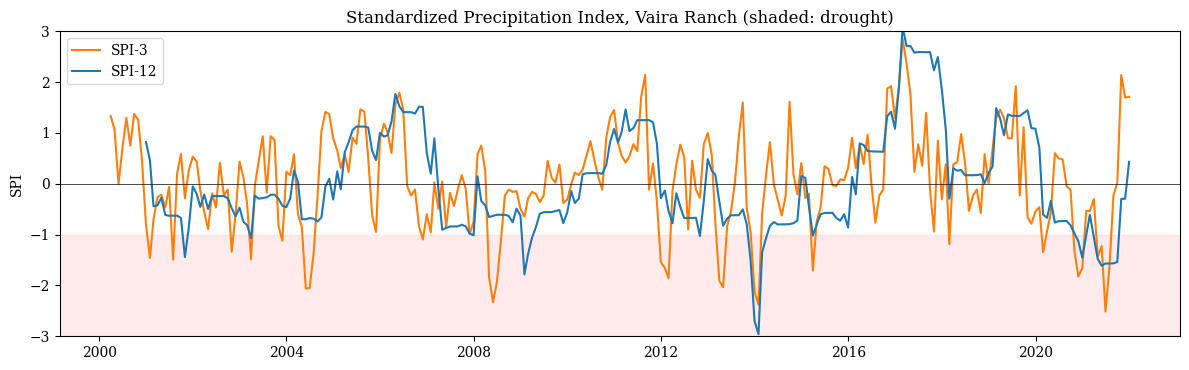

In [3]:
def spi(series, k):
    """Standardized index of a k-month running sum, gamma-fitted per calendar month with zero-precipitation handling."""
    x = series.rolling(k).sum()
    out = pd.Series(np.nan, index=x.index)
    for m in range(1, 13):
        sel = x[x.index.month == m].dropna()
        if len(sel) < 5: continue
        q = (sel == 0).mean()                                     # probability of zero
        pos = sel[sel > 0]
        a, loc, b = stats.gamma.fit(pos, floc=0)
        cdf = q + (1 - q) * stats.gamma.cdf(sel, a, loc=0, scale=b)
        cdf = np.clip(cdf, 1e-4, 1 - 1e-4)
        out.loc[sel.index] = stats.norm.ppf(cdf)
    return out

for k in [3, 6, 12]:
    mon[f'SPI{k}'] = spi(mon['P'], k)
fig, ax = plt.subplots(figsize=(12, 3.8))
for k, c in zip([3, 12], ['tab:orange', 'tab:blue']):
    ax.plot(mon.index, mon[f'SPI{k}'], color=c, label=f'SPI-{k}')
ax.axhspan(-3, -1, color='red', alpha=0.08); ax.axhline(0, color='k', lw=0.5); ax.set_ylim(-3, 3); ax.set_ylabel('SPI'); ax.legend()
ax.set_title('Standardized Precipitation Index, Vaira Ranch (shaded: drought)'); plt.tight_layout()

SPI-3 flickers with every wet or dry season; SPI-12 shows the multi-year droughts of 2007-2009 and 2012-2015 and the
wet year of 2017. The time scale you choose defines the drought you see: short scales for soil moisture and crops,
long scales for reservoirs and groundwater.

## **Step 2: SPEI**

SPEI-12 minus SPI-12: mean +0.00, trend over record -0.18 per decade


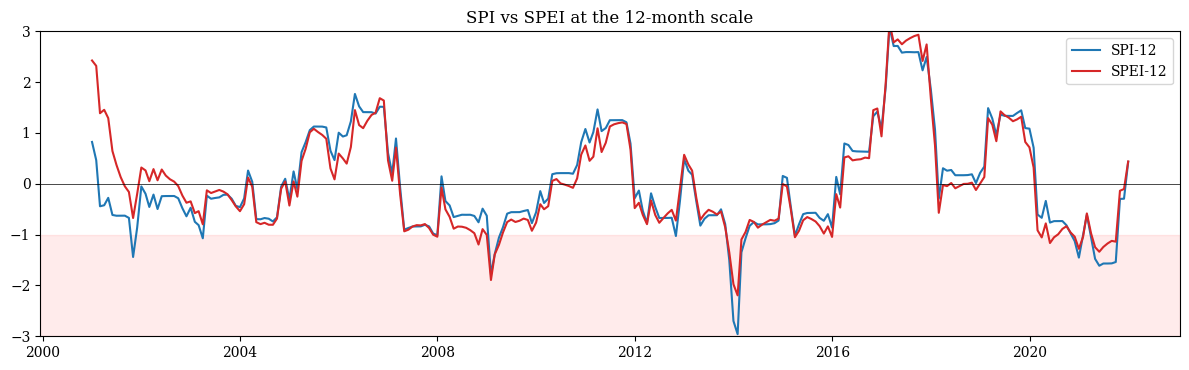

In [4]:
def spei(D, k, dist=stats.norm):
    """Standardized index of the k-month running sum of D = P - PET, fitted per calendar month.
    The reference method uses a three-parameter log-logistic distribution; with only ~22 values per month that fit is
    unstable, so the default here is a normal distribution. Pass another scipy distribution to experiment."""
    x = D.rolling(k).sum(); out = pd.Series(np.nan, index=x.index)
    for m in range(1, 13):
        sel = x[x.index.month == m].dropna()
        if len(sel) < 5: continue
        params = dist.fit(sel.values)
        cdf = np.clip(dist.cdf(sel.values, *params), 1e-4, 1 - 1e-4)
        out.loc[sel.index] = stats.norm.ppf(cdf)
    return out

mon['SPEI12'] = spei(mon['D'], 12); mon['SPEI3'] = spei(mon['D'], 3)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(mon.index, mon['SPI12'], color='tab:blue', label='SPI-12'); ax.plot(mon.index, mon['SPEI12'], color='tab:red', label='SPEI-12')
ax.axhspan(-3, -1, color='red', alpha=0.08); ax.axhline(0, color='k', lw=0.5); ax.set_ylim(-3, 3); ax.legend(); ax.set_title('SPI vs SPEI at the 12-month scale'); plt.tight_layout()
diff = (mon['SPEI12'] - mon['SPI12']).dropna()
print(f'SPEI-12 minus SPI-12: mean {diff.mean():+.2f}, trend over record {np.polyfit(np.arange(len(diff)), diff.values, 1)[0]*12*10:+.2f} per decade')

SPEI and SPI agree on when droughts happen. Where they differ is in years when evaporative demand was unusual: a hot
dry year is a deeper drought in SPEI than in SPI, and a cool dry year is milder. The printed difference and its trend
tell you whether demand has been adding to or offsetting the precipitation signal at this site. In a strongly warming
record the two indices drift apart, which is the argument for SPEI in climate change studies.

## **Step 3: The evaporative stress ratio**

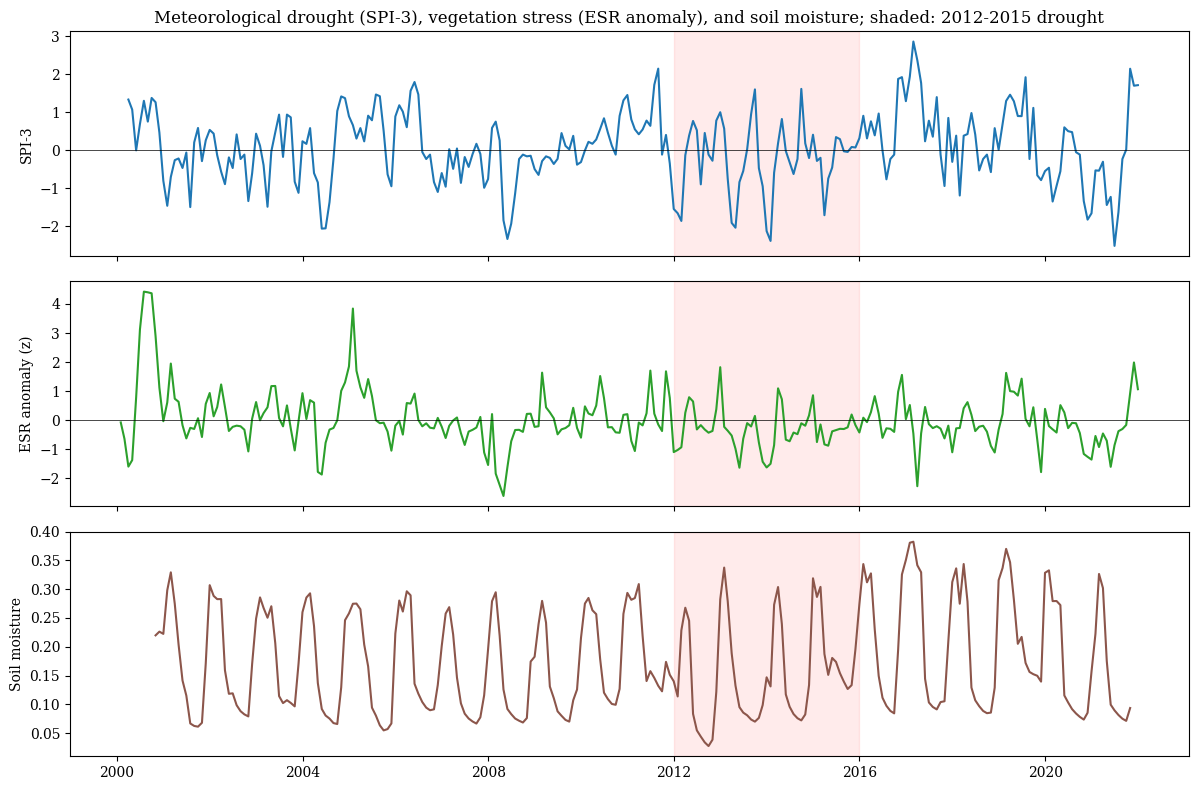

In [5]:
mon['ESR'] = mon['ET'] / mon['PET']
esr_clim = mon.groupby(mon.index.month)['ESR'].agg(['mean', 'std'])
mon['ESR_z'] = (mon['ESR'] - mon.index.month.map(esr_clim['mean']).values) / mon.index.month.map(esr_clim['std']).values
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(mon.index, mon['SPI3'], color='tab:blue'); axs[0].set_ylabel('SPI-3'); axs[0].axhline(0, color='k', lw=0.5)
axs[1].plot(mon.index, mon['ESR_z'], color='tab:green'); axs[1].set_ylabel('ESR anomaly (z)'); axs[1].axhline(0, color='k', lw=0.5)
axs[2].plot(mon.index, mon['SM'], color='tab:brown'); axs[2].set_ylabel('Soil moisture')
for ax in axs: ax.axvspan(pd.Timestamp('2012-01-01'), pd.Timestamp('2016-01-01'), color='red', alpha=0.08)
axs[0].set_title('Meteorological drought (SPI-3), vegetation stress (ESR anomaly), and soil moisture; shaded: 2012-2015 drought'); plt.tight_layout()

In [6]:
c = mon[['SPI3', 'SPI12', 'SPEI3', 'SPEI12', 'ESR_z', 'SM']].corr().round(2)
print('Correlation between monthly indices:'); print(c)

Correlation between monthly indices:
        SPI3  SPI12  SPEI3  SPEI12  ESR_z    SM
SPI3    1.00   0.53   0.82    0.46   0.45  0.25
SPI12   0.53   1.00   0.42    0.93   0.23  0.27
SPEI3   0.82   0.42   1.00    0.40   0.58  0.34
SPEI12  0.46   0.93   0.40    1.00   0.25  0.25
ESR_z   0.45   0.23   0.58    0.25   1.00  0.33
SM      0.25   0.27   0.34    0.25   0.33  1.00


**What to notice.** ESR follows soil moisture more closely than SPI does, because it measures what the vegetation is
actually doing. It also carries a seasonal signal of its own (ET is always far below PET in the dry summer), which is why
we standardize it by month. In a Mediterranean climate, the summer dry-down is not a drought; a drought is when the
winter rains fail. The indices agree on that when the time scale matches the process.

## **Exercises**

**Exercise 1.** Identify drought events as runs of at least three consecutive months with SPI-3 < -1. List their start, end, duration, and minimum SPI.

**Exercise 2.** Compute SPEI-3 with the FAO-56 reference ET from Notebook 02 instead of the site PET and compare the two SPEI series. How much does the PET method matter?

**Exercise 3.** Refit SPEI-12 with the log-logistic distribution (`spei(mon['D'], 12, dist=stats.fisk)`) and with the Pearson type III (`stats.pearson3`). Compare the three series, then bootstrap the 2014 value to see how uncertain the distribution choice makes it with a 22-year record.

**Exercise 4.** Compute ESR from weekly instead of monthly data. Find the fastest 4-week decline in ESR (a candidate flash drought) and check the precipitation and temperature during those weeks.

**Exercise 5.** Fit the SPI gamma distribution using only 2000-2010 and apply it to 2011-2021. How does the drought severity of 2012-2015 change with the reference period?

## **References**

- McKee, T. B., Doesken, N. J., & Kleist, J. (1993). The relationship of drought frequency and duration to time scales. *8th Conference on Applied Climatology*, 179-184.
- Vicente-Serrano, S. M., Begueria, S., & Lopez-Moreno, J. I. (2010). A multiscalar drought index sensitive to global warming: the SPEI. *Journal of Climate*, 23, 1696-1718.
- Anderson, M. C., et al. (2011). Evaluation of drought indices based on thermal remote sensing of evapotranspiration over the continental United States. *Journal of Climate*, 24, 2025-2044.
- Raghav, P., & Kumar, M. (2024). Are the ecosystem-level evaporative stress indices representative of evaporative stress of vegetation? *Agricultural and Forest Meteorology*, 357, 110195.